# CAB420 Assignment 1A Question 1: Template
Simon Denman (s.denman@qut.edu.au)

## Overview

This notebook provides a brief template for CAB420 Assignment 1A, Question 1. It implements the data loading, and splitting the data into the predictors and response. You are to use the data splits defined here in your response.

The template also provides other suggestions around how to approach the problem.

Please make sure you read the assignment brief on canvas, and check the FAQ for other information.

**Note: File paths used in this template may need to change for your local machine. Please set these based on your local file system structure.**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import statsmodels.api as sm
from scipy.stats import jarque_bera

In [3]:
# load data
train = pd.read_csv('Data/Q1/communities_train.csv')
val = pd.read_csv('Data/Q1/communities_val.csv')
test = pd.read_csv('Data/Q1/communities_test.csv')

# Pull out X and y components of the data
# if you want to convert this data to numpy format, you can add .to_numpy() to the end of each row below
# split predictors and response
X_train = train.iloc[:, 0:-1]
y_train = train.iloc[:, -1]

X_val = val.iloc[:, 0:-1]
y_val = val.iloc[:, -1]

X_test = test.iloc[:, 0:-1]
y_test = test.iloc[:, -1]

print("Train shape:", train.shape)
print("Validation shape:", val.shape)
print("Test shape:", test.shape)
print("Missing values in train:", train.isna().sum().sum())

Train shape: (298, 101)
Validation shape: (298, 101)
Test shape: (299, 101)
Missing values in train: 0


## Quick Inspection + Preprocessing

In [10]:
# basic inspection
print(X_train.describe().T[['mean', 'std', 'min', 'max']].head())
print("Target summary:")
print(y_train.describe())

# standardise predictors for ridge and lasso only
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

                    mean       std   min   max
population      0.051174  0.105366  0.00  1.00
householdsize   0.470168  0.174496  0.08  1.00
racepctblack    0.187550  0.256605  0.00  1.00
racePctWhite    0.740436  0.247056  0.00  0.99
racePctAsian    0.161846  0.219377  0.00  1.00
Target summary:
count    298.000000
mean       0.231879
std        0.212650
min        0.010000
25%        0.070000
50%        0.160000
75%        0.340000
max        1.000000
Name:  ViolentCrimesPerPop , dtype: float64


## Linear Regression

In [5]:
# train your Linear Regression model here. Data has already been split into predictors (X_train, X_val and X_test) and the
# desired response (y_train, y_val and y_test above).
#
# Note that you DO NOT NEED to remove any variables, or add higher order terms. JUST USE THE DATA AS IS.
#

# Once you've trained the model, evaluate it. This would include:
#  - Measuring the accuracy of the model (i.e. RMSE or similar measures)
#  - Looking at the properties of the fitted model, for example the R^2, and if all terms are contributing to the model
#  - Considering the validity of the trained model. This could include assumptions about independent predictors, and the 
#    distribution of the residuals
# Your write-up should include your findings regarding the above.

In [6]:
# sklearn linear regression for predictions
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# predictions
lr_train_pred = lr_model.predict(X_train)
lr_val_pred = lr_model.predict(X_val)
lr_test_pred = lr_model.predict(X_test)

# metrics function
def regression_metrics(y_true, y_pred, model_name, split_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {
        "Model": model_name,
        "Split": split_name,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    }

results = []
results.append(regression_metrics(y_train, lr_train_pred, "Linear Regression", "Train"))
results.append(regression_metrics(y_val, lr_val_pred, "Linear Regression", "Validation"))
results.append(regression_metrics(y_test, lr_test_pred, "Linear Regression", "Test"))

results_df = pd.DataFrame(results)
print(results_df)

               Model       Split      RMSE       MAE        R2
0  Linear Regression       Train  0.104200  0.079247  0.759085
1  Linear Regression  Validation  0.154912  0.116405  0.620929
2  Linear Regression        Test  0.153292  0.115499  0.553067


## Statsmodels OLS summary

In [7]:
X_train_sm = sm.add_constant(X_train)
ols_model = sm.OLS(y_train, X_train_sm).fit()

print(ols_model.summary())

                              OLS Regression Results                             
Dep. Variable:      ViolentCrimesPerPop    R-squared:                       0.759
Model:                               OLS   Adj. R-squared:                  0.637
Method:                    Least Squares   F-statistic:                     6.207
Date:                   Wed, 01 Apr 2026   Prob (F-statistic):           7.72e-28
Time:                           03:43:36   Log-Likelihood:                 251.07
No. Observations:                    298   AIC:                            -300.1
Df Residuals:                        197   BIC:                             73.27
Df Model:                            100                                         
Covariance Type:               nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------

## Residual Diagnostics For Linear Regression

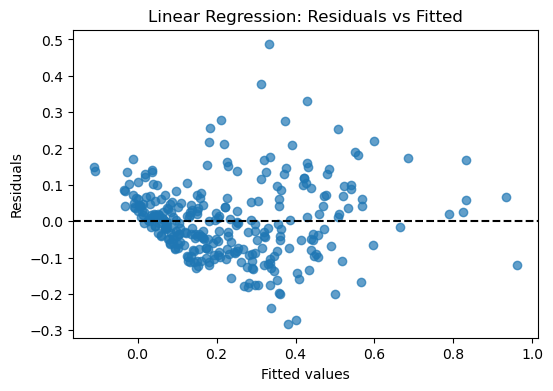

<Figure size 600x400 with 0 Axes>

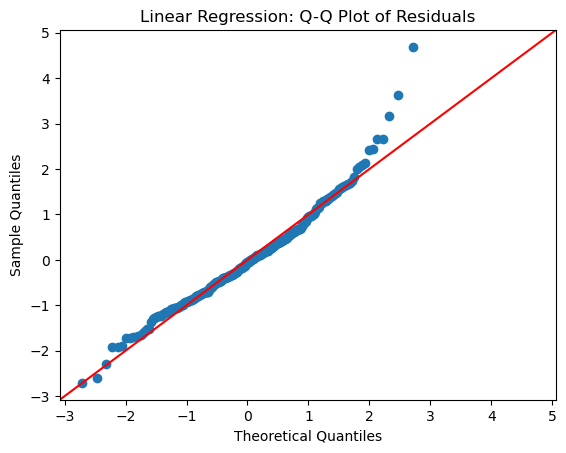

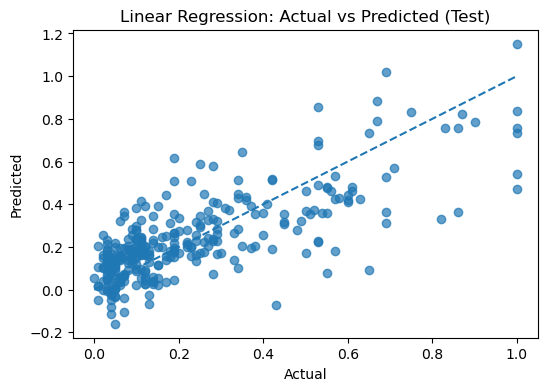

Jarque-Bera statistic: 67.08347105406165
Jarque-Bera p-value: 2.7102499629253994e-15


In [8]:
# residuals on training set
lr_residuals = y_train - lr_train_pred

# residuals vs fitted
plt.figure(figsize=(6,4))
plt.scatter(lr_train_pred, lr_residuals, alpha=0.7)
plt.axhline(0, color='black', linestyle='--')
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Linear Regression: Residuals vs Fitted")
plt.show()

# Q-Q plot
plt.figure(figsize=(6,4))
sm.qqplot(lr_residuals, line='45', fit=True)
plt.title("Linear Regression: Q-Q Plot of Residuals")
plt.show()

# actual vs predicted
plt.figure(figsize=(6,4))
plt.scatter(y_test, lr_test_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], linestyle='--')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Linear Regression: Actual vs Predicted (Test)")
plt.show()

# Jarque-Bera test for normality
jb_stat, jb_p = jarque_bera(lr_residuals)
print("Jarque-Bera statistic:", jb_stat)
print("Jarque-Bera p-value:", jb_p)

In [ ]:
# train your regularised models (ridge and lasso). Here you will use the same data as you used in for the above regression model
#
# One key consideration with your regularised models is the selection of lambda (i.e. the strength of the regularisation). A suggested 
# starting point for finding your value of lambda is suggested below using numpy.logspace (see 
# https://numpy.org/doc/stable/reference/generated/numpy.logspace.html). The code below will give you 50 values starting at 10-10 and 
# finishing at 1, spread on a log scale. Just note that for plotting things that result from this, you may want to change the scale of 
# your x-axis to a log scale (see https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.xscale.html)
#
# Note that the below list of lambda is going to be fairly coarse. For the sake of speed, we suggest that you avoid evaluating a huge
# number of lambdas in one pass, but you can get a more precise estimate by refining your estimate over multiple passes (i.e. if your
# initial estimate if 0.1, you could run the search again now looking over a range of [0.01 .. 1.0] or similar). If you wish to do this,
# we suggest limiting yourself to 2-3 passes at most. You do not need to get the perfect value of lambda.
#
# remember that lambda is a keyword in python, so we're calling the array below alphas. 
#
alphas = numpy.logspace(-10, 0)

# Once you've found your ridge and lasso models, evaluate them, following the approach you've used for the linear method, and compare the
# three models.

Best Ridge alpha: 1.0
Best Ridge validation RMSE: 0.14605044382918503


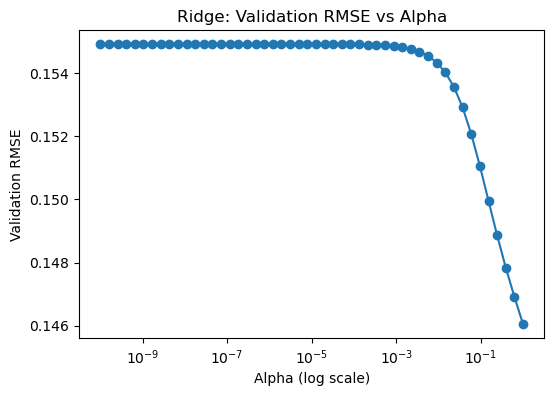

In [11]:
ridge_alphas = np.logspace(-10, 0, 50)

ridge_val_rmse = []

for alpha in ridge_alphas:
    ridge_model = Ridge(alpha=alpha)
    ridge_model.fit(X_train_scaled, y_train)
    val_pred = ridge_model.predict(X_val_scaled)
    rmse = np.sqrt(mean_squared_error(y_val, val_pred))
    ridge_val_rmse.append(rmse)

best_ridge_idx = np.argmin(ridge_val_rmse)
best_ridge_alpha = ridge_alphas[best_ridge_idx]

print("Best Ridge alpha:", best_ridge_alpha)
print("Best Ridge validation RMSE:", ridge_val_rmse[best_ridge_idx])

plt.figure(figsize=(6,4))
plt.plot(ridge_alphas, ridge_val_rmse, marker='o')
plt.xscale('log')
plt.xlabel("Alpha (log scale)")
plt.ylabel("Validation RMSE")
plt.title("Ridge: Validation RMSE vs Alpha")
plt.show()

In [13]:
ridge_model = Ridge(alpha=best_ridge_alpha)
ridge_model.fit(X_train_scaled, y_train)

ridge_train_pred = ridge_model.predict(X_train_scaled)
ridge_val_pred = ridge_model.predict(X_val_scaled)
ridge_test_pred = ridge_model.predict(X_test_scaled)

results.append(regression_metrics(y_train, ridge_train_pred, "Ridge", "Train"))
results.append(regression_metrics(y_val, ridge_val_pred, "Ridge", "Validation"))
results.append(regression_metrics(y_test, ridge_test_pred, "Ridge", "Test"))

results_df = pd.DataFrame(results)
print(results_df)

               Model       Split      RMSE       MAE        R2
0  Linear Regression       Train  0.104200  0.079247  0.759085
1  Linear Regression  Validation  0.154912  0.116405  0.620929
2  Linear Regression        Test  0.153292  0.115499  0.553067
3              Ridge       Train  0.106655  0.080721  0.747600
4              Ridge  Validation  0.146050  0.107793  0.663058
5              Ridge        Test  0.142702  0.106966  0.612683


Best Lasso alpha: 0.0009658832241158698
Best Lasso validation RMSE: 0.1431717909512117
Non-zero coefficients: 61


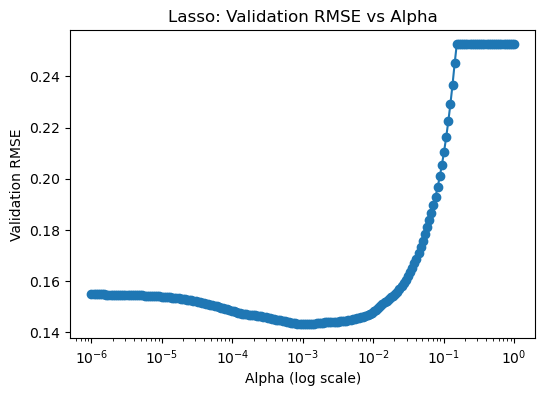

In [14]:
lasso_alphas = np.logspace(-6, 0, 200)

lasso_val_rmse = []
lasso_nonzero = []

for alpha in lasso_alphas:
    lasso_model = Lasso(alpha=alpha, max_iter=50000)
    lasso_model.fit(X_train_scaled, y_train)
    val_pred = lasso_model.predict(X_val_scaled)
    rmse = np.sqrt(mean_squared_error(y_val, val_pred))
    lasso_val_rmse.append(rmse)
    lasso_nonzero.append(np.sum(lasso_model.coef_ != 0))

best_lasso_idx = np.argmin(lasso_val_rmse)
best_lasso_alpha = lasso_alphas[best_lasso_idx]

print("Best Lasso alpha:", best_lasso_alpha)
print("Best Lasso validation RMSE:", lasso_val_rmse[best_lasso_idx])
print("Non-zero coefficients:", lasso_nonzero[best_lasso_idx])

plt.figure(figsize=(6,4))
plt.plot(lasso_alphas, lasso_val_rmse, marker='o')
plt.xscale('log')
plt.xlabel("Alpha (log scale)")
plt.ylabel("Validation RMSE")
plt.title("Lasso: Validation RMSE vs Alpha")
plt.show()

In [15]:
lasso_model = Lasso(alpha=best_lasso_alpha, max_iter=50000)
lasso_model.fit(X_train_scaled, y_train)

lasso_train_pred = lasso_model.predict(X_train_scaled)
lasso_val_pred = lasso_model.predict(X_val_scaled)
lasso_test_pred = lasso_model.predict(X_test_scaled)

results.append(regression_metrics(y_train, lasso_train_pred, "Lasso", "Train"))
results.append(regression_metrics(y_val, lasso_val_pred, "Lasso", "Validation"))
results.append(regression_metrics(y_test, lasso_test_pred, "Lasso", "Test"))

results_df = pd.DataFrame(results)
print(results_df)

print("Number of non-zero coefficients:", np.sum(lasso_model.coef_ != 0))

               Model       Split      RMSE       MAE        R2
0  Linear Regression       Train  0.104200  0.079247  0.759085
1  Linear Regression  Validation  0.154912  0.116405  0.620929
2  Linear Regression        Test  0.153292  0.115499  0.553067
3              Ridge       Train  0.106655  0.080721  0.747600
4              Ridge  Validation  0.146050  0.107793  0.663058
5              Ridge        Test  0.142702  0.106966  0.612683
6              Lasso       Train  0.112613  0.084688  0.718612
7              Lasso  Validation  0.143172  0.102226  0.676209
8              Lasso        Test  0.131024  0.096065  0.673481
Number of non-zero coefficients: 61


In [16]:
final_results = pd.DataFrame(results)
print(final_results)

pivot_rmse = final_results.pivot(index="Model", columns="Split", values="RMSE")
pivot_r2 = final_results.pivot(index="Model", columns="Split", values="R2")

print("\nRMSE Table")
print(pivot_rmse)

print("\nR2 Table")
print(pivot_r2)

               Model       Split      RMSE       MAE        R2
0  Linear Regression       Train  0.104200  0.079247  0.759085
1  Linear Regression  Validation  0.154912  0.116405  0.620929
2  Linear Regression        Test  0.153292  0.115499  0.553067
3              Ridge       Train  0.106655  0.080721  0.747600
4              Ridge  Validation  0.146050  0.107793  0.663058
5              Ridge        Test  0.142702  0.106966  0.612683
6              Lasso       Train  0.112613  0.084688  0.718612
7              Lasso  Validation  0.143172  0.102226  0.676209
8              Lasso        Test  0.131024  0.096065  0.673481

RMSE Table
Split                  Test     Train  Validation
Model                                            
Lasso              0.131024  0.112613    0.143172
Linear Regression  0.153292  0.104200    0.154912
Ridge              0.142702  0.106655    0.146050

R2 Table
Split                  Test     Train  Validation
Model                                           

In [ ]:
# For your write-up, you should include:
# - a discussion of any pre-processing you did and why; or why you left the data as-is
# - a discussion of how you selected the values of lambda used in your regularised models, and what those values are
# - a comparison of three models, considering both the accuracy and validity of the models, as outlined above, this means:
#   > accuracy of the model
#   > measures of fit, such as R^2
#   > testing assumptions about the independence of predictors, and the distribution of the residuals
# - A discussion of the ethical concerns that need to be considered when evaluating the models developed for this problem
# Your write-up should be supported by appropriate figures and tables. Figures and tables should have numbers and meaningful captions. 
# Note that figures and tables are not included in the page limits.
#
# SEE THE ASSIGNMENT BRIEF ON CANVAS FOR MORE DETAILS AND NOTE THAT A NOTEBOOK FILE DOES NOT CONSTITUTE A VALID SUBMISSION. 
# YOU SHOULD WRITE UP YOUR RESPONSE IN A SEPARATE DOCUMENT